In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset



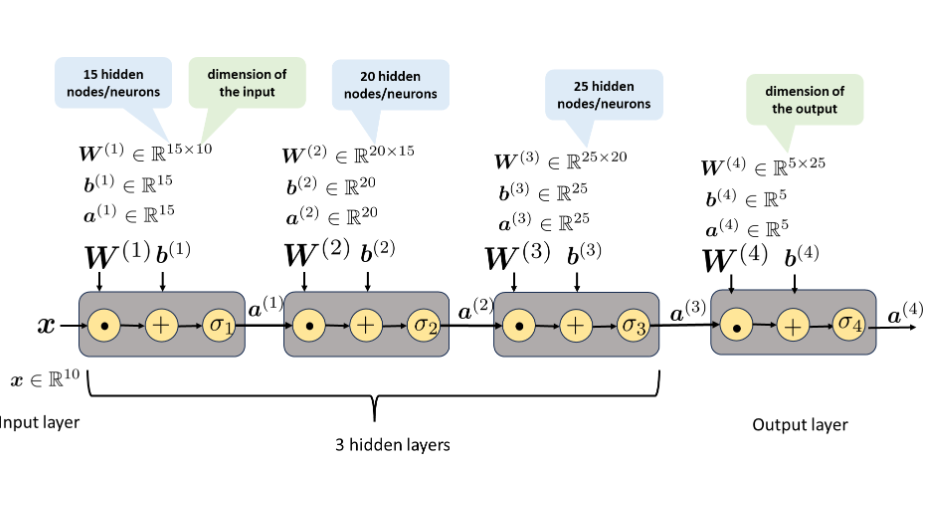

In [ ]:


class FCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10, 15) #nn.Linear(in_features, out_features)
        self.fc2 = nn.Linear(15, 20)
        self.fc3 = nn.Linear(20, 25)
        self.fc4 = nn.Linear(25, 5)
        self.dropout = nn.Dropout(p=0.5)

        self.act1 = nn.ReLU()
        self.act2 = nn.ReLU()
        self.act3 = nn.ReLU()
        self.act4 = nn.Softmax()


    def forward(self, x):
        x = self.dropout(self.act1(self.fc1(x))) # 10 -> 15
        x = self.act2(self.fc2(x))  # 15 -> 20
        x = self.act3(self.fc3(x))  # 20 -> 25
        x = self.act4(self.fc4(x))  # 25 -> 5
        return x


In [ ]:
model=FCNN()

In [ ]:
x=torch.rand(8,10)
model.train()
y = model.dropout(model.fc1(x))
print(y)


tensor([[ 0.0000e+00,  1.1896e+00,  0.0000e+00,  2.1275e-01,  1.3203e+00,
         -0.0000e+00,  0.0000e+00, -5.6255e-01, -0.0000e+00,  0.0000e+00,
         -0.0000e+00, -1.1367e-01,  0.0000e+00,  0.0000e+00,  8.5687e-02],
        [ 0.0000e+00,  1.6066e+00, -0.0000e+00, -0.0000e+00,  1.1575e+00,
          7.2264e-03,  1.8254e+00, -0.0000e+00, -0.0000e+00,  0.0000e+00,
          0.0000e+00, -0.0000e+00,  8.2491e-01,  2.7010e-01,  0.0000e+00],
        [ 0.0000e+00,  1.5999e+00,  2.7463e-01, -2.4679e-01,  5.6871e-01,
         -3.5411e-02,  1.6735e+00, -0.0000e+00, -8.2464e-01,  0.0000e+00,
          0.0000e+00, -1.4057e-01,  0.0000e+00,  3.4633e-01, -2.5898e-01],
        [-2.6265e-01,  0.0000e+00,  0.0000e+00, -3.4503e-01,  0.0000e+00,
          0.0000e+00,  1.2843e+00, -0.0000e+00, -0.0000e+00,  0.0000e+00,
          0.0000e+00,  0.0000e+00,  0.0000e+00,  8.6253e-01,  0.0000e+00],
        [-5.1789e-02,  0.0000e+00,  3.2037e-01, -7.6988e-01,  0.0000e+00,
          0.0000e+00,  0.0000e+00,

In [ ]:
torch.manual_seed(0)
N = 2000
X = torch.randn(N, 10)
y = torch.randint(low=0, high=5, size=(N,))

dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=64, shuffle=True, drop_last=False)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FCNN().to(device)
criterion = nn.CrossEntropyLoss()

# Mini-batch SGD with weight decay (L2 regularization)
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=1e-4,
)

# LR scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [ ]:
print(device)

cuda


In [ ]:

num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)

    scheduler.step()

    avg_loss = total_loss / total
    acc = correct / total
    print(f"Epoch {epoch+1:02d} | loss={avg_loss:.4f} | acc={acc:.4f} | lr={scheduler.get_last_lr()[0]:.4g}")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Epoch 01 | loss=1.6093 | acc=0.2110 | lr=0.1
Epoch 02 | loss=1.6087 | acc=0.2215 | lr=0.1
Epoch 03 | loss=1.6082 | acc=0.2165 | lr=0.1
Epoch 04 | loss=1.6081 | acc=0.2160 | lr=0.1
Epoch 05 | loss=1.6080 | acc=0.2160 | lr=0.1
Epoch 06 | loss=1.6077 | acc=0.2160 | lr=0.1
Epoch 07 | loss=1.6077 | acc=0.2185 | lr=0.1
Epoch 08 | loss=1.6073 | acc=0.2190 | lr=0.1
Epoch 09 | loss=1.6073 | acc=0.2180 | lr=0.1
Epoch 10 | loss=1.6069 | acc=0.2220 | lr=0.05
Epoch 11 | loss=1.6064 | acc=0.2245 | lr=0.05
Epoch 12 | loss=1.6063 | acc=0.2265 | lr=0.05
Epoch 13 | loss=1.6060 | acc=0.2285 | lr=0.05
Epoch 14 | loss=1.6057 | acc=0.2280 | lr=0.05
Epoch 15 | loss=1.6056 | acc=0.2245 | lr=0.05
Epoch 16 | loss=1.6052 | acc=0.2280 | lr=0.05
Epoch 17 | loss=1.6052 | acc=0.2260 | lr=0.05
Epoch 18 | loss=1.6044 | acc=0.2260 | lr=0.05
Epoch 19 | loss=1.6040 | acc=0.2300 | lr=0.05
Epoch 20 | loss=1.6034 | acc=0.2300 | lr=0.025


In [ ]:
model = FCNN()
x = torch.randn(8, 10)
y = model.forward(x)
print(y.shape)

torch.Size([8, 5])


In [ ]:
print(y)

tensor([[0.1932, 0.2036, 0.2172, 0.1695, 0.2165],
        [0.1957, 0.2057, 0.2052, 0.1781, 0.2153],
        [0.1911, 0.2072, 0.2198, 0.1648, 0.2171],
        [0.1955, 0.2030, 0.2167, 0.1695, 0.2153],
        [0.1932, 0.2029, 0.2146, 0.1765, 0.2129],
        [0.1920, 0.2107, 0.2177, 0.1715, 0.2080],
        [0.1928, 0.2057, 0.2159, 0.1717, 0.2140],
        [0.1881, 0.2081, 0.2178, 0.1663, 0.2196]], grad_fn=<SoftmaxBackward0>)


In [ ]:
print(model.fc2.weight.shape)

torch.Size([20, 15])


In [ ]:
print(y.sum(dim=1))

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
       grad_fn=<SumBackward1>)


In [ ]:
for name, param in model.named_parameters():
    print(f"Parameter: {name}, Shape: {param.shape}")

Parameter: fc1.weight, Shape: torch.Size([15, 10])
Parameter: fc1.bias, Shape: torch.Size([15])
Parameter: fc2.weight, Shape: torch.Size([20, 15])
Parameter: fc2.bias, Shape: torch.Size([20])
Parameter: fc3.weight, Shape: torch.Size([25, 20])
Parameter: fc3.bias, Shape: torch.Size([25])
Parameter: fc4.weight, Shape: torch.Size([5, 25])
Parameter: fc4.bias, Shape: torch.Size([5])


In [ ]:
print(model.fc1.weight)

Parameter containing:
tensor([[-0.1632,  0.3032, -0.0431, -0.3095, -0.2684, -0.2832, -0.1438,  0.0179,
          0.1761,  0.1537],
        [-0.2487,  0.1120, -0.2581, -0.2548, -0.2864,  0.2505, -0.0075, -0.1248,
          0.0015,  0.0626],
        [ 0.1928,  0.0543,  0.0641, -0.2083, -0.2397, -0.2798, -0.0464,  0.1548,
         -0.2727,  0.3158],
        [-0.1153,  0.0661,  0.0937, -0.3037,  0.1223,  0.1891,  0.1757,  0.0248,
          0.0632, -0.0108],
        [ 0.1795, -0.2061, -0.2652,  0.0687,  0.2551, -0.2643, -0.2944,  0.1226,
          0.2497,  0.0310],
        [-0.2629, -0.2117, -0.1606,  0.0230, -0.3056,  0.2433,  0.0170,  0.2418,
         -0.1808,  0.3053],
        [ 0.2377,  0.2969,  0.2895,  0.3146, -0.2026,  0.1309, -0.1173,  0.1455,
         -0.0887, -0.1783],
        [ 0.2475, -0.0921, -0.0848, -0.0653,  0.1107, -0.1273,  0.1902,  0.2846,
         -0.0795, -0.0600],
        [-0.1585,  0.0239,  0.1327,  0.2448,  0.3078,  0.2847,  0.0461, -0.1463,
         -0.0806, -0.0976

In [ ]:
model.fc1.weight.requires_grad = True

In [ ]:
print(model.fc1.weight)

Parameter containing:
tensor([[-0.1632,  0.3032, -0.0431, -0.3095, -0.2684, -0.2832, -0.1438,  0.0179,
          0.1761,  0.1537],
        [-0.2487,  0.1120, -0.2581, -0.2548, -0.2864,  0.2505, -0.0075, -0.1248,
          0.0015,  0.0626],
        [ 0.1928,  0.0543,  0.0641, -0.2083, -0.2397, -0.2798, -0.0464,  0.1548,
         -0.2727,  0.3158],
        [-0.1153,  0.0661,  0.0937, -0.3037,  0.1223,  0.1891,  0.1757,  0.0248,
          0.0632, -0.0108],
        [ 0.1795, -0.2061, -0.2652,  0.0687,  0.2551, -0.2643, -0.2944,  0.1226,
          0.2497,  0.0310],
        [-0.2629, -0.2117, -0.1606,  0.0230, -0.3056,  0.2433,  0.0170,  0.2418,
         -0.1808,  0.3053],
        [ 0.2377,  0.2969,  0.2895,  0.3146, -0.2026,  0.1309, -0.1173,  0.1455,
         -0.0887, -0.1783],
        [ 0.2475, -0.0921, -0.0848, -0.0653,  0.1107, -0.1273,  0.1902,  0.2846,
         -0.0795, -0.0600],
        [-0.1585,  0.0239,  0.1327,  0.2448,  0.3078,  0.2847,  0.0461, -0.1463,
         -0.0806, -0.0976

In [ ]:
print(model.fc3.weight.grad)

None


In [ ]:
x = torch.randn(8, 10)               # input
y_true = torch.randn(8, 5)           # target (example for regression)

criterion = nn.MSELoss()
y_pred = model.forward(x)
loss = criterion(y_pred, y_true)

model.zero_grad()


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


In [ ]:
print(model.fc3.weight.grad)

None


In [ ]:
loss.backward()

print(model.fc3.weight.grad.shape)         # gradient tensor (15x10)
print(model.fc1.bias.grad)           # gradient tensor (15,)

torch.Size([25, 20])
tensor([ 0.0015,  0.0013,  0.0013,  0.0007,  0.0006,  0.0002, -0.0015, -0.0006,
        -0.0002,  0.0007,  0.0005, -0.0004, -0.0002, -0.0010, -0.0004])
